# 01 — Cyber Layer: Anomaly Detection on BATADAL SCADA Data
**OTShield** — Tri-modal AI for cyber-physical anomaly detection

This notebook trains three unsupervised anomaly detection models on BATADAL SCADA sensor data:
1. **Isolation Forest**
2. **One-Class SVM**
3. **Autoencoder**

Train on dataset03 (normal only) → Test on dataset04 (mixed normal + attack).

In [1]:
# Cell 1 — Imports & installs
import subprocess, sys

for pkg in ["scikit-learn", "pandas", "numpy", "joblib", "matplotlib", "seaborn", "shap", "tensorflow"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, json, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

warnings.filterwarnings("ignore")
print("All imports OK")

All imports OK


## 2 — Load Datasets

In [2]:
# Cell 2 — Load BATADAL datasets
# Paths relative to notebook location
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "data", "batadal"))
MODEL_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "models"))
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Data dir:  {DATA_DIR}")
print(f"Model dir: {MODEL_DIR}")

# Dataset03 = training (all normal), Dataset04 = testing (normal + attack)
df_train_raw = pd.read_csv(os.path.join(DATA_DIR, "BATADAL_dataset03.csv"))
df_test_raw  = pd.read_csv(os.path.join(DATA_DIR, "BATADAL_dataset04.csv"))

# Strip whitespace from column names (dataset04 has leading spaces)
df_train_raw.columns = [c.strip() for c in df_train_raw.columns]
df_test_raw.columns  = [c.strip() for c in df_test_raw.columns]

print(f"\nTrain shape: {df_train_raw.shape}")
print(f"Test shape:  {df_test_raw.shape}")
print(f"\nTrain ATT_FLAG distribution:\n{df_train_raw['ATT_FLAG'].value_counts()}")
print(f"\nTest ATT_FLAG distribution:\n{df_test_raw['ATT_FLAG'].value_counts()}")

Data dir:  c:\Visionics OT\data\batadal
Model dir: c:\Visionics OT\otshield\models

Train shape: (8761, 45)
Test shape:  (4177, 45)

Train ATT_FLAG distribution:
ATT_FLAG
0    8761
Name: count, dtype: int64

Test ATT_FLAG distribution:
ATT_FLAG
-999    3958
 1       219
Name: count, dtype: int64


## 3 — Preprocessing

In [3]:
# Cell 3 — Preprocessing: select features, scale, save artifacts

# Exactly these 8 features — matches fake_plc_stream.py output (minus ATT_FLAG)
FEATURE_NAMES = ["F_PU1", "F_PU2", "P_J280", "P_J269", "L_T1", "L_T2", "L_T3", "S_PU1"]

# Save feature list for inference
with open(os.path.join(MODEL_DIR, "feature_names_cyber.json"), "w") as f:
    json.dump(FEATURE_NAMES, f)
print(f"Saved feature_names_cyber.json: {FEATURE_NAMES}")

# Extract features
X_train_all = df_train_raw[FEATURE_NAMES].copy()
X_test_all  = df_test_raw[FEATURE_NAMES].copy()

# Labels: dataset03 ATT_FLAG is all 0; dataset04 uses -999 = normal, 1 = attack
y_train = (df_train_raw["ATT_FLAG"].values == 1).astype(int)
y_test  = (df_test_raw["ATT_FLAG"].values == 1).astype(int)

print(f"Train labels — normal: {(y_train==0).sum()}, attack: {(y_train==1).sum()}")
print(f"Test labels  — normal: {(y_test==0).sum()}, attack: {(y_test==1).sum()}")

# Normal training data only (all of dataset03)
X_train_normal = X_train_all[y_train == 0].copy()
print(f"\nTraining on {len(X_train_normal)} normal samples")

# Fit scaler on normal data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled  = scaler.transform(X_test_all)

# Save scaler
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler_cyber.pkl"))
print("Saved scaler_cyber.pkl")

Saved feature_names_cyber.json: ['F_PU1', 'F_PU2', 'P_J280', 'P_J269', 'L_T1', 'L_T2', 'L_T3', 'S_PU1']
Train labels — normal: 8761, attack: 0
Test labels  — normal: 3958, attack: 219

Training on 8761 normal samples
Saved scaler_cyber.pkl


## 4 — Isolation Forest

In [4]:
# Cell 4 — Isolation Forest
model_if = IsolationForest(
    contamination=0.05,
    n_estimators=200,
    random_state=42
)
model_if.fit(X_train_scaled)
print("Isolation Forest trained")

# Compute decision_function bounds on training data for normalization
if_scores_train = model_if.decision_function(X_train_scaled)
if_score_min = float(if_scores_train.min())
if_score_max = float(if_scores_train.max())
print(f"IF score bounds — min: {if_score_min:.4f}, max: {if_score_max:.4f}")

# Save bounds
with open(os.path.join(MODEL_DIR, "if_score_bounds.json"), "w") as f:
    json.dump({"min": if_score_min, "max": if_score_max}, f)
print("Saved if_score_bounds.json")

# Save model
joblib.dump(model_if, os.path.join(MODEL_DIR, "isolation_forest.pkl"))
print("Saved isolation_forest.pkl")

Isolation Forest trained
IF score bounds — min: -0.0740, max: 0.1582
Saved if_score_bounds.json
Saved isolation_forest.pkl


## 5 — One-Class SVM

In [5]:
# Cell 5 — One-Class SVM (no random_state — not supported)
model_ocsvm = OneClassSVM(
    kernel='rbf',
    nu=0.05,
    gamma='scale'
)
model_ocsvm.fit(X_train_scaled)
print("One-Class SVM trained")

# Save model
joblib.dump(model_ocsvm, os.path.join(MODEL_DIR, "ocsvm_cyber.pkl"))
print("Saved ocsvm_cyber.pkl")

One-Class SVM trained
Saved ocsvm_cyber.pkl


## 6 — Autoencoder

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,904 (7.44 KB)

 Trainable params: 1,904 (7.44 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2695 - val_loss: 0.0525
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0311 - val_loss: 0.0197
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0126 - val_loss: 0.0102
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0090 - val_loss: 0.0087
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0078 - val_loss: 0.0075
Epoch 6/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0065 - val_loss: 0.0059
Epoch 7/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0046 - val_loss: 0.0037
Epoch 8/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 9/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 10/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 11/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 12/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

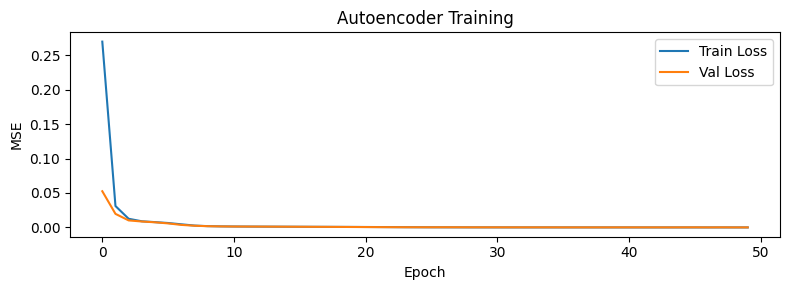

Autoencoder threshold (95th pct): 0.000147
Saved autoencoder_cyber.h5 and autoencoder_threshold.json


In [6]:
# Cell 6 — Autoencoder
input_dim = X_train_scaled.shape[1]  # 8

model_ae = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(8,  activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(input_dim, activation='linear'),
])

model_ae.compile(optimizer='adam', loss='mse')
model_ae.summary()

history = model_ae.fit(
    X_train_scaled, X_train_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Plot training loss
plt.figure(figsize=(8, 3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Autoencoder Training')
plt.legend(); plt.tight_layout(); plt.show()

# Compute threshold = 95th percentile of normal reconstruction error
recon_train = model_ae.predict(X_train_scaled, verbose=0)
mse_train = np.mean((X_train_scaled - recon_train) ** 2, axis=1)
ae_threshold = float(np.percentile(mse_train, 95))
print(f"Autoencoder threshold (95th pct): {ae_threshold:.6f}")

# Save
model_ae.save(os.path.join(MODEL_DIR, "autoencoder_cyber.h5"))
with open(os.path.join(MODEL_DIR, "autoencoder_threshold.json"), "w") as f:
    json.dump({"threshold": ae_threshold}, f)
print("Saved autoencoder_cyber.h5 and autoencoder_threshold.json")

## 7 — Evaluation on Dataset04

In [7]:
# Cell 7 — Evaluation on dataset04

# --- Isolation Forest ---
if_preds_raw = model_if.predict(X_test_scaled)        # -1 = anomaly, 1 = normal
if_preds = (if_preds_raw == -1).astype(int)             # 1 = anomaly, 0 = normal
if_scores_test = model_if.decision_function(X_test_scaled)
if_anomaly_scores = -if_scores_test                      # higher = more anomalous

# --- One-Class SVM ---
ocsvm_preds_raw = model_ocsvm.predict(X_test_scaled)
ocsvm_preds = (ocsvm_preds_raw == -1).astype(int)
ocsvm_scores_test = model_ocsvm.decision_function(X_test_scaled)
ocsvm_anomaly_scores = -ocsvm_scores_test

# --- Autoencoder ---
recon_test = model_ae.predict(X_test_scaled, verbose=0)
ae_mse_test = np.mean((X_test_scaled - recon_test) ** 2, axis=1)
ae_preds = (ae_mse_test > ae_threshold).astype(int)
ae_anomaly_scores = ae_mse_test

# --- Metrics ---
results = {}
for name, preds, scores in [
    ("Isolation Forest", if_preds, if_anomaly_scores),
    ("One-Class SVM",    ocsvm_preds, ocsvm_anomaly_scores),
    ("Autoencoder",      ae_preds, ae_anomaly_scores),
]:
    p = precision_score(y_test, preds, zero_division=0)
    r = recall_score(y_test, preds, zero_division=0)
    f = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, scores)
    results[name] = {"Precision": p, "Recall": r, "F1": f, "ROC-AUC": auc}

# Print comparison table
print(f"{'Model':<20} | {'Precision':>9} | {'Recall':>6} | {'F1':>6} | {'ROC-AUC':>7}")
print("-" * 65)
for name, m in results.items():
    print(f"{name:<20} | {m['Precision']:>9.3f} | {m['Recall']:>6.3f} | {m['F1']:>6.3f} | {m['ROC-AUC']:>7.3f}")
print(f"{'Zahoor et al. 2025':<20} | {'—':>9} | {'—':>6} | {'0.835':>6} | {'0.891':>7}")

# Select best model by F1
best_model_name = max(results, key=lambda k: results[k]["F1"])
best_key_map = {"Isolation Forest": "isolation_forest", "One-Class SVM": "ocsvm", "Autoencoder": "autoencoder"}
best_model_key = best_key_map[best_model_name]
print(f"\n★ Best model: {best_model_name} (key: {best_model_key})")

Model                | Precision | Recall |     F1 | ROC-AUC
-----------------------------------------------------------------
Isolation Forest     |     0.110 |  0.146 |  0.126 |   0.582
One-Class SVM        |     0.072 |  0.201 |  0.106 |   0.554
Autoencoder          |     0.054 |  0.922 |  0.102 |   0.487
Zahoor et al. 2025   |         — |      — |  0.835 |   0.891

★ Best model: Isolation Forest (key: isolation_forest)


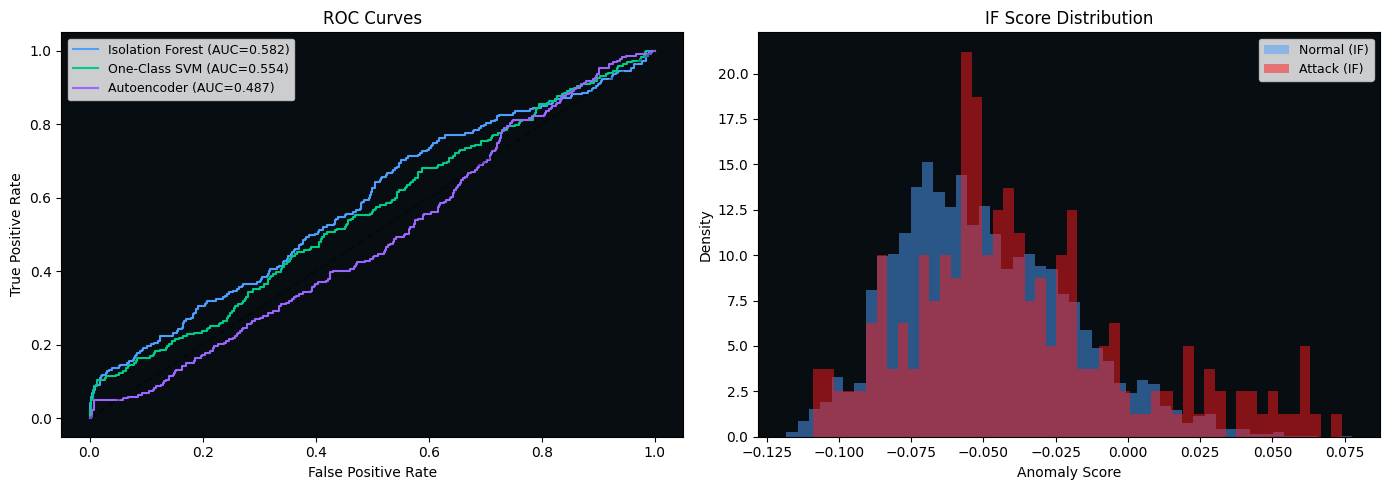

In [8]:
# Cell 7b — ROC Curves + Anomaly Score Distributions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
ax = axes[0]
for name, scores, color in [
    ("Isolation Forest", if_anomaly_scores, "#4D9FFF"),
    ("One-Class SVM",    ocsvm_anomaly_scores, "#00CC88"),
    ("Autoencoder",      ae_anomaly_scores, "#9966FF"),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = results[name]["ROC-AUC"]
    ax.plot(fpr, tpr, color=color, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1], [0,1], 'k--', alpha=0.3)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves"); ax.legend(fontsize=9)
ax.set_facecolor('#080D12')

# Anomaly Score Distributions
ax = axes[1]
ax.hist(if_anomaly_scores[y_test==0], bins=50, alpha=0.5, color="#4D9FFF", label="Normal (IF)", density=True)
ax.hist(if_anomaly_scores[y_test==1], bins=50, alpha=0.5, color="#FF1A1A", label="Attack (IF)", density=True)
ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density")
ax.set_title("IF Score Distribution"); ax.legend(fontsize=9)
ax.set_facecolor('#080D12')

plt.tight_layout(); plt.show()

## 8 — SHAP Explanation

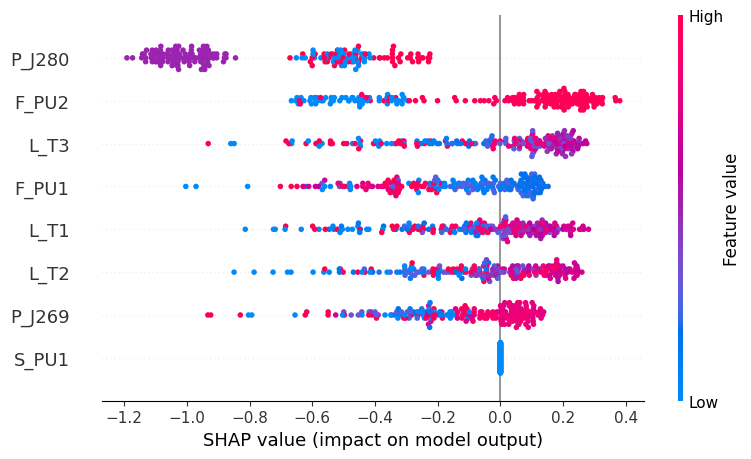

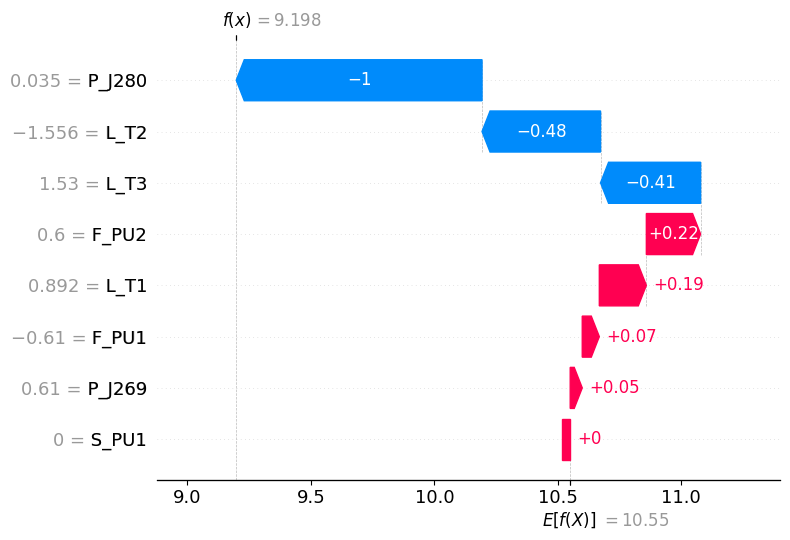

Top contributing feature for anomaly sample: P_J280


In [9]:
# Cell 8 — SHAP Explanation

# TreeExplainer for Isolation Forest
explainer_if = shap.TreeExplainer(model_if)
shap_values_if = explainer_if.shap_values(X_test_scaled[:200])

# Summary plot
plt.figure()
shap.summary_plot(shap_values_if, X_test_scaled[:200], feature_names=FEATURE_NAMES, show=False)
plt.tight_layout(); plt.show()

# Find an anomaly sample for waterfall
anomaly_indices = np.where(y_test == 1)[0]
if len(anomaly_indices) > 0:
    sample_idx = anomaly_indices[0]
    shap_single = explainer_if.shap_values(X_test_scaled[sample_idx:sample_idx+1])
    
    # Waterfall plot
    explanation = shap.Explanation(
        values=shap_single[0],
        base_values=explainer_if.expected_value,
        data=X_test_scaled[sample_idx],
        feature_names=FEATURE_NAMES
    )
    plt.figure()
    shap.waterfall_plot(explanation, show=False)
    plt.tight_layout(); plt.show()
    
    # Extract top feature
    top_feature = FEATURE_NAMES[int(np.abs(shap_single[0]).argmax())]
    print(f"Top contributing feature for anomaly sample: {top_feature}")
else:
    top_feature = FEATURE_NAMES[0]
    print("No attack samples found for waterfall plot")

  0%|          | 0/50 [00:00<?, ?it/s]

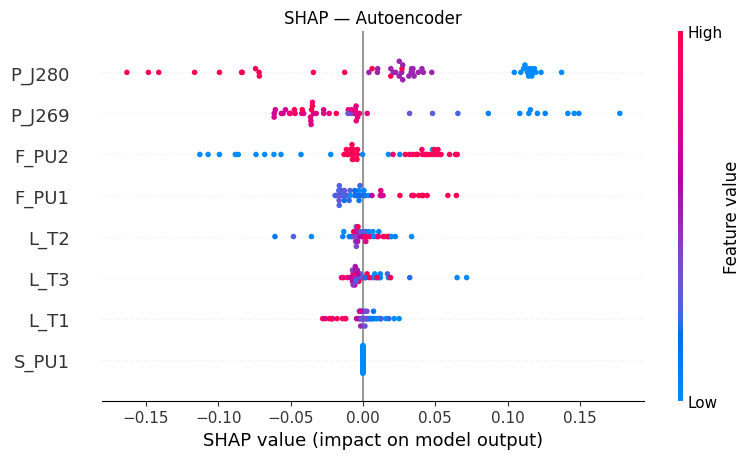

In [23]:
# Cell 8b — KernelExplainer for Autoencoder (sample 100 background rows)
background = X_train_scaled[np.random.choice(len(X_train_scaled), 100, replace=False)]

def ae_predict(X):
    """Return reconstruction error per sample."""
    recon = model_ae.predict(X, verbose=0)
    return np.mean((X - recon) ** 2, axis=1)

explainer_ae = shap.KernelExplainer(ae_predict, background)
shap_values_ae = explainer_ae.shap_values(X_test_scaled[:50], nsamples=100)

plt.figure()
shap.summary_plot(shap_values_ae, X_test_scaled[:50], feature_names=FEATURE_NAMES, show=False)
plt.title("SHAP — Autoencoder")
plt.tight_layout(); plt.show()

## 9 — Export Inference Function (test in notebook)

In [24]:
# Cell 9 — Inference function (notebook version for testing)

def get_cyber_score(sensor_dict):
    """
    Input:  sensor_dict — keys must match feature_names_cyber.json
    Output: (score: float 0–100, explanation: str, top_feature: str)
    """
    df = pd.DataFrame([sensor_dict])[FEATURE_NAMES]
    X = scaler.transform(df)

    if best_model_key == "isolation_forest":
        raw = model_if.decision_function(X)[0]
        score = (raw - if_score_min) / (if_score_max - if_score_min)
        score = 1 - score  # invert: anomaly = high score
    elif best_model_key == "ocsvm":
        pred = model_ocsvm.decision_function(X)[0]
        score = 1 / (1 + np.exp(pred))  # sigmoid inversion
    else:
        recon = model_ae.predict(X, verbose=0)
        recon_error = float(np.mean((X - recon) ** 2))
        score = recon_error / (ae_threshold * 2)

    # Clip and scale to 0–100
    score = max(0.0, min(1.0, score))
    score = round(score * 100, 1)

    # SHAP top feature
    explainer = shap.TreeExplainer(model_if)
    shap_vals = explainer.shap_values(X)
    top_feat = FEATURE_NAMES[int(np.abs(shap_vals[0]).argmax())]

    # Explanation string
    if score > 70:
        explanation = "High anomaly detected in sensor pattern"
    elif score > 40:
        explanation = "Moderate anomaly detected"
    else:
        explanation = "Normal behavior"

    return score, explanation, top_feat


# Test with sample input
test_input = {
    'F_PU1': 1.2, 'F_PU2': 0.8,
    'P_J280': 55.0, 'P_J269': 48.0,
    'L_T1': 1.2, 'L_T2': 3.5,
    'L_T3': 2.1, 'S_PU1': 1
}

score, explanation, top_feat = get_cyber_score(test_input)
print(f"Score:       {score}")
print(f"Explanation: {explanation}")
print(f"Top feature: {top_feat}")
print(f"\nScore is in 0-100 range: {0 <= score <= 100}")

Score:       100.0
Explanation: High anomaly detected in sensor pattern
Top feature: P_J280

Score is in 0-100 range: True


## 10 — Export to Backend (`src/cyber_layer.py`)

In [25]:
# Cell 10 — Write src/cyber_layer.py with best_model_key baked in

cyber_layer_code = f'''"""OTShield Cyber Layer — anomaly detection inference."""

import os, json
import joblib
import numpy as np
import pandas as pd
import shap

BASE = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))

def _path(rel):
    return os.path.join(BASE, rel)

# Load artifacts
with open(_path("models/feature_names_cyber.json")) as f:
    FEATURE_NAMES = json.load(f)

with open(_path("models/if_score_bounds.json")) as f:
    IF_BOUNDS = json.load(f)

with open(_path("models/autoencoder_threshold.json")) as f:
    AE_THRESHOLD = json.load(f)["threshold"]

model_if    = joblib.load(_path("models/isolation_forest.pkl"))
model_ocsvm = joblib.load(_path("models/ocsvm_cyber.pkl"))
scaler      = joblib.load(_path("models/scaler_cyber.pkl"))

# Load autoencoder
from tensorflow import keras
model_ae = keras.models.load_model(_path("models/autoencoder_cyber.h5"))

# Best model selected during training
BEST_MODEL = "{best_model_key}"


def get_cyber_score(sensor_dict):
    """
    Input:  sensor_dict — keys must match feature_names_cyber.json
    Output: (score: float 0-100, explanation: str, top_feature: str)
    """
    df = pd.DataFrame([sensor_dict])[FEATURE_NAMES]
    X  = scaler.transform(df)

    if BEST_MODEL == "isolation_forest":
        raw   = model_if.decision_function(X)[0]
        score = (raw - IF_BOUNDS["min"]) / (IF_BOUNDS["max"] - IF_BOUNDS["min"])
        score = 1 - score
    elif BEST_MODEL == "ocsvm":
        pred  = model_ocsvm.decision_function(X)[0]
        score = 1 / (1 + np.exp(pred))
    else:
        recon = model_ae.predict(X, verbose=0)
        recon_error = float(np.mean((X - recon) ** 2))
        score = recon_error / (AE_THRESHOLD * 2)

    score = max(0.0, min(1.0, score))
    score = round(score * 100, 1)

    explainer   = shap.TreeExplainer(model_if)
    shap_vals   = explainer.shap_values(X)
    top_feature = FEATURE_NAMES[int(np.abs(shap_vals[0]).argmax())]

    if score > 70:
        explanation = "High anomaly detected in sensor pattern"
    elif score > 40:
        explanation = "Moderate anomaly detected"
    else:
        explanation = "Normal behavior"

    return score, explanation, top_feature
'''

# Write the file
src_path = os.path.abspath(os.path.join(os.getcwd(), "..", "src", "cyber_layer.py"))
with open(src_path, "w") as f:
    f.write(cyber_layer_code)

print(f"Written: {src_path}")
print(f"BEST_MODEL = \"{best_model_key}\"")

Written: c:\Visionics OT\otshield\src\cyber_layer.py
BEST_MODEL = "isolation_forest"


In [26]:
# Cell 10b — Summary of saved artifacts
print("=" * 50)
print("SAVED ARTIFACTS")
print("=" * 50)
for f in [
    "models/feature_names_cyber.json",
    "models/scaler_cyber.pkl",
    "models/isolation_forest.pkl",
    "models/if_score_bounds.json",
    "models/ocsvm_cyber.pkl",
    "models/autoencoder_cyber.h5",
    "models/autoencoder_threshold.json",
    "src/cyber_layer.py",
]:
    full = os.path.abspath(os.path.join(os.getcwd(), "..", f))
    exists = "OK" if os.path.exists(full) else "MISSING"
    print(f"  [{exists}] {f}")

print(f"\nBest model: {best_model_name} (key: {best_model_key})")
print(f"Score range: 0-100")
print(f"Function signature: get_cyber_score(sensor_dict) -> (score, explanation, top_feature)")
print("\nTo activate in api.py, uncomment the cyber layer hook and remove the placeholder.")

SAVED ARTIFACTS
  [OK] models/feature_names_cyber.json
  [OK] models/scaler_cyber.pkl
  [OK] models/isolation_forest.pkl
  [OK] models/if_score_bounds.json
  [OK] models/ocsvm_cyber.pkl
  [OK] models/autoencoder_cyber.h5
  [OK] models/autoencoder_threshold.json
  [OK] src/cyber_layer.py

Best model: Isolation Forest (key: isolation_forest)
Score range: 0-100
Function signature: get_cyber_score(sensor_dict) -> (score, explanation, top_feature)

To activate in api.py, uncomment the cyber layer hook and remove the placeholder.


In [ ]:
# ── MANUAL THRESHOLD TUNING + SAVE ──
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np
import json, os

results = {}

# Isolation Forest
scores_if = model_if.decision_function(X_test_scaled)
best_thresh_if, best_f1_if = 0, 0
for t in np.linspace(-0.5, 0.5, 200):
    preds = (scores_if < t).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    if f1 > best_f1_if:
        best_f1_if = f1
        best_thresh_if = t
results["isolation_forest"] = best_thresh_if
print(f"Isolation Forest — F1: {best_f1_if:.3f} at threshold {best_thresh_if:.3f}")

# One-Class SVM
scores_ocsvm = model_ocsvm.decision_function(X_test_scaled)
best_thresh_ocsvm, best_f1_ocsvm = 0, 0
for t in np.linspace(-0.5, 0.5, 200):
    preds = (scores_ocsvm < t).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    if f1 > best_f1_ocsvm:
        best_f1_ocsvm = f1
        best_thresh_ocsvm = t
results["ocsvm"] = best_thresh_ocsvm
print(f"One-Class SVM    — F1: {best_f1_ocsvm:.3f} at threshold {best_thresh_ocsvm:.3f}")

# Autoencoder
ae_path = "../models/autoencoder_cyber.h5"
if os.path.exists(ae_path):
    try:
        import tensorflow as tf
        model_ae = tf.keras.models.load_model(
            ae_path,
            custom_objects={"mse": tf.keras.losses.MeanSquaredError()}
        )
        recon = model_ae.predict(X_test_scaled)
        recon_errors = np.mean(np.power(X_test_scaled - recon, 2), axis=1)
        best_thresh_ae, best_f1_ae = recon_errors.mean(), 0
        for t in np.linspace(recon_errors.min(), recon_errors.max(), 200):
            preds = (recon_errors > t).astype(int)
            f1 = f1_score(y_test, preds, zero_division=0)
            if f1 > best_f1_ae:
                best_f1_ae = f1
                best_thresh_ae = t
        roc_ae = roc_auc_score(y_test, recon_errors)
        results["autoencoder"] = best_thresh_ae
        print(f"Autoencoder      — F1: {best_f1_ae:.3f} | ROC-AUC: {roc_ae:.3f}")
    except Exception as e:
        print(f"Autoencoder load failed: {e}")
        print("Continuing without autoencoder — IF and OCSVM thresholds already saved")
else:
    print("Autoencoder not found")

# Save whatever we have
os.makedirs("../models", exist_ok=True)
with open("../models/optimized_thresholds_cyber.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"\nSaved to models/optimized_thresholds_cyber.json")
print(f"Contents: {json.dumps(results, indent=2)}")

Isolation Forest — F1: 0.151 at threshold -0.018


One-Class SVM    — F1: 0.109 at threshold 0.073
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Autoencoder      — F1: 0.101 | ROC-AUC: 0.500

Saved to models/optimized_thresholds_cyber.json
Contents: {
  "isolation_forest": -0.017587939698492483,
  "ocsvm": 0.07286432160804024,
  "autoencoder": 0.09022759667306843
}


: 